In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f4 
function_folder = os.path.join(base_dir, "function_4")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f4 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 4: shape = {df_f4.shape}, columns = {df_f4.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']


In [3]:
week1_results = {"f4": ([0.439369, 0.276427, 0.360198, 0.470119], -1.8014266350928305)}

In [4]:
week2_results = {"f4": ([0.542100, 0.336200, 0.419500, 0.404000], -2.041748838194795)}

In [5]:
week3_results = {"f4": ([0.402906, 0.437778, 0.329101, 0.424377], 0.07045398603133579)}

In [6]:
week4_results = {"f4": ([0.351926, 0.442039, 0.451511, 0.443953], -0.27637133038944084)}

In [7]:
week5_results = {"f4": ([0.342113, 0.430851, 0.327587, 0.458906], -0.49820890718197175)}

In [8]:
week6_results = {"f4": ([0.378009, 0.410452, 0.389136, 0.370426], 0.34655132659709453)}

In [9]:
week7_results = {"f4": ([0.402435, 0.485938, 0.405691, 0.380615], -1.5762466920468117)}

In [10]:
week8_results = {"f4": ([0.413226, 0.408926, 0.383757, 0.471737], -0.9393775297880427)}

In [11]:
week9_results = {"f4": ([0.378009, 0.230452, 0.389136, 0.550426], -4.6298356823203015)}

In [12]:
week10_results = {"f4": ([0.393437, 0.413310, 0.349543, 0.408827], 0.5545122853059294)}

In [13]:
week11_results = {"f4": ([0.400800, 0.416211, 0.324678, 0.408967], -0.02563374723946721)}

In [14]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
    "week11": week11_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f4

for week, results in weekly_results.items():
    
    if "f4" not in results:
        continue
    
    inputs, output = results["f4"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f4
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "X4", "y1"]
    )
    
    # append to df_f4
    df_f4 = pd.concat([df_f4, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f4 = df_f4.drop_duplicates(ignore_index=True)

print("updated f4 shape:", df_f4.shape)


updated f4 shape: (41, 5)


In [15]:
print(df_f4)

          X1        X2        X3        X4         y1
0   0.896981  0.725628  0.175404  0.701694 -22.108288
1   0.889356  0.499588  0.539269  0.508783 -14.601397
2   0.250946  0.033693  0.145380  0.494932 -11.699932
3   0.346962  0.006250  0.760564  0.613024 -16.053765
4   0.124871  0.129770  0.384400  0.287076 -10.069633
5   0.801303  0.500231  0.706645  0.195103 -15.487083
6   0.247708  0.060445  0.042186  0.441324 -12.681685
7   0.746702  0.757092  0.369353  0.206566 -16.026400
8   0.400665  0.072574  0.886768  0.243842 -17.049235
9   0.626071  0.586751  0.438806  0.778858 -12.741766
10  0.957135  0.597644  0.766114  0.776210 -27.316396
11  0.732812  0.145250  0.476813  0.133366 -13.527649
12  0.655115  0.072392  0.687152  0.081517 -16.679115
13  0.219734  0.832031  0.482864  0.082569 -16.507159
14  0.488594  0.211965  0.939178  0.376192 -17.817999
15  0.167130  0.876555  0.217240  0.959801 -26.561821
16  0.216911  0.166086  0.241372  0.770062 -12.758324
17  0.387488  0.804532  0.75

In [16]:
display(df_f4.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,41.0,0.505622,0.259343,0.037825,0.342113,0.402906,0.732812,0.985622
X2,41.0,0.453718,0.268688,0.006250,0.230452,0.442039,0.664853,0.919592
X3,41.0,0.441479,0.227346,0.042186,0.324678,0.389136,0.539269,0.939178
X4,41.0,0.463786,0.250881,0.081517,0.253924,0.443953,0.613024,0.999483
y1,41.0,-12.877438,9.521869,-32.625660,-17.817999,-13.122782,-4.025542,0.554512


## Feature vs y scatter plots


Feature vs y1 for f4


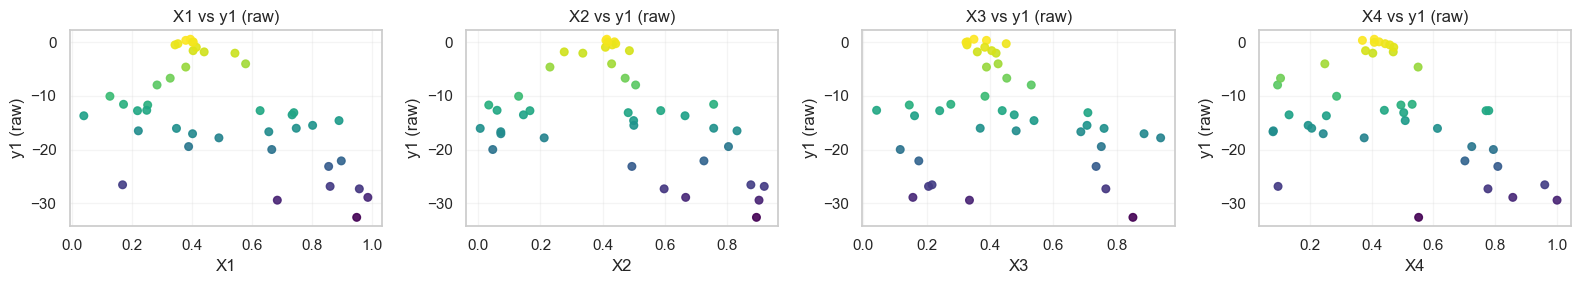

In [17]:
print("\nFeature vs y1 for f4")

# extract inputs and output for f4
input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
X_f4 = df_f4[input_cols_f4].values
y_f4 = df_f4["y1"].values

# number of input features
n_features = X_f4.shape[1]
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

# robust flattening
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.ravel().tolist()

# plot each feature
for j, col in enumerate(input_cols_f4):
    ax = axes[j]
    sc = ax.scatter(
        X_f4[:, j],
        y_f4,
        c=y_f4,
        cmap="viridis",
        s=30,
        alpha=0.9
    )
    ax.set_xlabel(col)
    ax.set_ylabel("y1 (raw)")
    ax.set_title(f"{col} vs y1 (raw)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Correlation Analysis

df_f4: Consolidated Correlation Analysis
Agreement = Pearson and Spearman similar in sign and magnitude.
Nonlinear monotonic structure = Spearman >> Pearson or sign mismatch.

feature   pearson  spearman   kendall  pearson_spearman_diff status
     X1 -0.518578 -0.452285 -0.303844               0.066293  agree
     X2 -0.405979 -0.406446 -0.275610               0.000467  agree
     X3 -0.191597 -0.175095 -0.174497               0.016502  agree
     X4 -0.395207 -0.333972 -0.239024               0.061235  agree


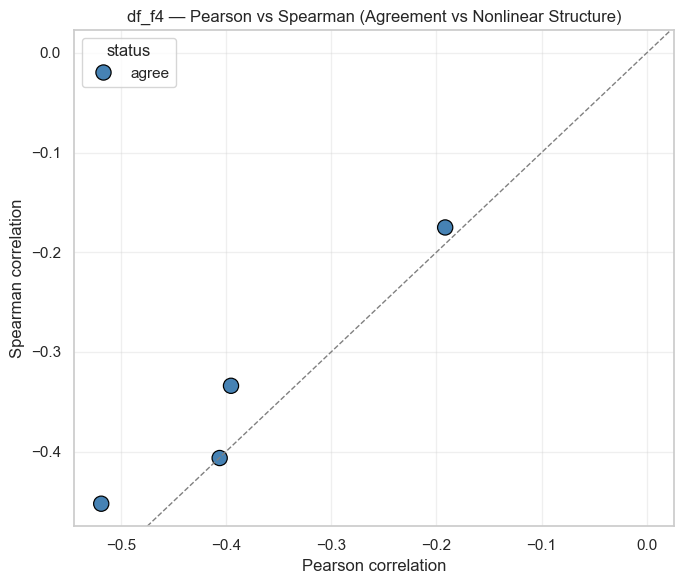

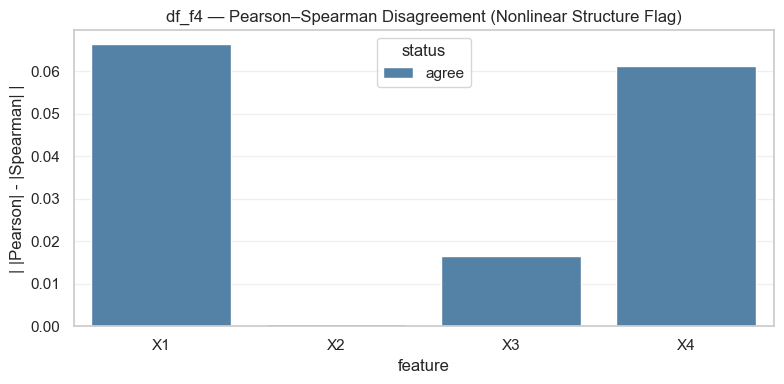

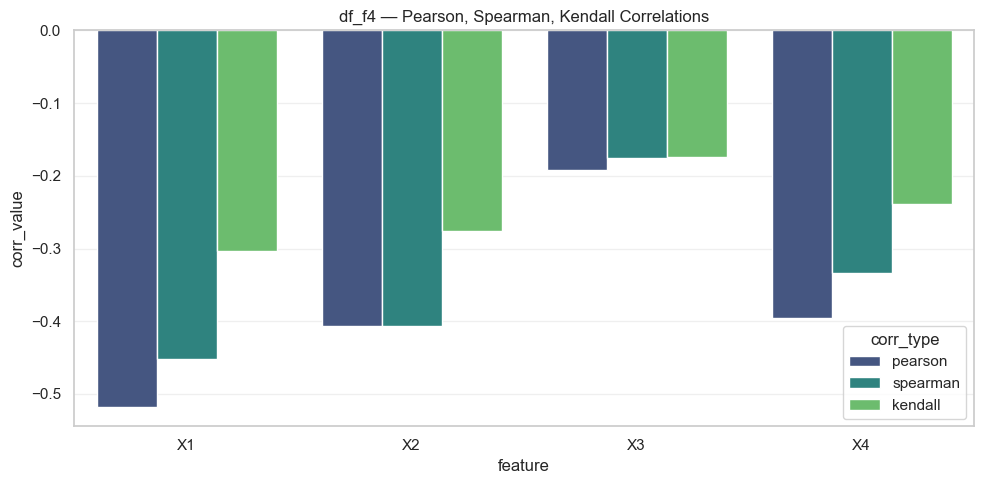

In [18]:
from scipy.stats import pearsonr, spearmanr, kendalltau


# Consolidated correlation analysis for df_f4
def consolidated_correlation(df_f4, y_col="y1", threshold=0.15):
    """
    Consolidated Pearson–Spearman–Kendall correlation analysis for df_f4,
    with diagnostics and visuals.
    """

    # Extract inputs and output
    input_cols = [c for c in df_f4.columns if c.startswith("X")]
    X = df_f4[input_cols]
    y = df_f4[y_col].values

    rows = []

    # Compute correlations
    for col in input_cols:
        x = df_f4[col].values

        pear, _ = pearsonr(x, y)
        spear, _ = spearmanr(x, y)
        kend, _ = kendalltau(x, y)

        sign_agree = np.sign(pear) == np.sign(spear)
        mag_diff = abs(abs(pear) - abs(spear))

        if sign_agree and mag_diff < threshold:
            status = "agree"
        else:
            status = "nonlinear monotonic structure"

        rows.append({
            "feature": col,
            "pearson": pear,
            "spearman": spear,
            "kendall": kend,
            "pearson_spearman_diff": mag_diff,
            "status": status
        })

    df_corr = pd.DataFrame(rows)


    # Print Table
    print("df_f4: Consolidated Correlation Analysis")
    print("Agreement = Pearson and Spearman similar in sign and magnitude.")
    print("Nonlinear monotonic structure = Spearman >> Pearson or sign mismatch.\n")
    print(df_corr.to_string(index=False))

    # Pearson vs Spearman scatter
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        data=df_corr,
        x="pearson",
        y="spearman",
        hue="status",
        palette={"agree": "steelblue", "nonlinear monotonic structure": "darkorange"},
        s=120,
        edgecolor="black"
    )
    plt.axline((0, 0), slope=1, color="gray", linestyle="--", linewidth=1)
    plt.title("df_f4 — Pearson vs Spearman (Agreement vs Nonlinear Structure)")
    plt.xlabel("Pearson correlation")
    plt.ylabel("Spearman correlation")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # Nonlinear structure flag plot
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=df_corr,
        x="feature",
        y="pearson_spearman_diff",
        hue="status",
        palette={"agree": "steelblue", "nonlinear monotonic structure": "darkorange"}
    )
    plt.title("df_f4 — Pearson–Spearman Disagreement (Nonlinear Structure Flag)")
    plt.ylabel("| |Pearson| - |Spearman| |")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Per-feature correlation bars
    df_melt = df_corr.melt(
        id_vars=["feature"],
        value_vars=["pearson", "spearman", "kendall"],
        var_name="corr_type",
        value_name="corr_value"
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=df_melt,
        x="feature",
        y="corr_value",
        hue="corr_type",
        palette="viridis"
    )
    plt.title("df_f4 — Pearson, Spearman, Kendall Correlations")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_corr


corr_f4 = consolidated_correlation(df_f4)



## Mutual Information & Partial Correlation

In [19]:
!pip install pingouin
import pingouin as pg
from scipy.stats import t
from numpy.linalg import inv

In [20]:
print("f4 — Partial Correlation with Holm–Bonferroni Correction")

# copy raw f4
df_f4_raw = df_f4.copy()

# define inputs and output
input_cols_f4 = [c for c in df_f4_raw.columns if c.startswith("X")]
output_col_f4 = "y1"

# store results for correction
pcorr_results = []

# compute partial correlations for each X feature
for x in input_cols_f4:
    covars = [c for c in input_cols_f4 if c != x]  # all other X's as covariates
    
    pcorr_raw_f4 = pg.partial_corr(
        data=df_f4_raw,
        x=x,
        y=output_col_f4,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f4)
    
    # store for correction
    pcorr_results.append({
        "feature": x,
        "partial_corr": pcorr_raw_f4["r"].values[0],
        "p_value": pcorr_raw_f4["p-val"].values[0]
    })

# convert to dataframe
df_pcorr = pd.DataFrame(pcorr_results)

# sort by p-value for Holm–Bonferroni
df_pcorr = df_pcorr.sort_values("p_value").reset_index(drop=True)

m = len(df_pcorr)
holm_p = []

# Holm–Bonferroni adjusted p-values
for i, p in enumerate(df_pcorr["p_value"]):
    adj = (m - i) * p
    holm_p.append(min(adj, 1.0))

df_pcorr["holm_bonferroni_p"] = holm_p
df_pcorr["significant"] = df_pcorr["holm_bonferroni_p"] < 0.05

print("df_f4: Consolidated Partial Correlations with Holm–Bonferroni Correction")
display(df_pcorr)



f4 — Partial Correlation with Holm–Bonferroni Correction

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,41,-0.38286,"[-0.63, -0.07]",0.01767



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,41,-0.319243,"[-0.58, 0.0]",0.05074



Partial correlation for X3:


,n,r,CI95%,p-val
pearson,41,-0.182327,"[-0.47, 0.15]",0.273251



Partial correlation for X4:


,n,r,CI95%,p-val
pearson,41,-0.354508,"[-0.61, -0.04]",0.028976


df_f4: Consolidated Partial Correlations with Holm–Bonferroni Correction


,feature,partial_corr,p_value,holm_bonferroni_p,significant
0,X1,-0.382860,0.017670,0.070681,False
1,X4,-0.354508,0.028976,0.086928,False
2,X2,-0.319243,0.050740,0.101481,False
3,X3,-0.182327,0.273251,0.273251,False


In [21]:
from sklearn.feature_selection import mutual_info_regression


def mutual_information_f4(df_f4, pcorr_df, y_col="y1"):
    """
    Compute MI for df_f4 and integrate with partial correlations.
    MI is used only as a secondary confirmation signal.
    """

    # extract inputs and output
    input_cols = [c for c in df_f4.columns if c.startswith("X")]
    X = df_f4[input_cols].values
    y = df_f4[y_col].values

    # compute MI
    mi_vals = mutual_info_regression(X, y, random_state=0)

    df_mi = pd.DataFrame({
        "feature": input_cols,
        "mutual_information": mi_vals
    })

    # merge with partial correlations
    df_merge = pcorr_df.merge(df_mi, on="feature")

    # agreement flag
    df_merge["mi_pcorr_agree"] = (
        np.sign(df_merge["partial_corr"]) == np.sign(df_merge["mutual_information"])
    )

    # interpretive label
    df_merge["interpretation"] = np.where(
        df_merge["significant"] & df_merge["mi_pcorr_agree"],
        "confirmed (PCorr + MI agree)",
        np.where(
            df_merge["significant"] & ~df_merge["mi_pcorr_agree"],
            "PCorr only (MI unreliable)",
            "inactive"
        )
    )

    print("df_f4: Mutual Information (Secondary Diagnostic)")
    print("MI is used only as a cross-check. Partial correlations dominate.\n")
    display(df_merge)

    return df_merge

# run after computing pcorr_f4
mi_f4 = mutual_information_f4(df_f4, df_pcorr)


df_f4: Mutual Information (Secondary Diagnostic)
MI is used only as a cross-check. Partial correlations dominate.



,feature,partial_corr,p_value,holm_bonferroni_p,significant,mutual_information,mi_pcorr_agree,interpretation
0,X1,-0.382860,0.017670,0.070681,False,0.500910,False,inactive
1,X4,-0.354508,0.028976,0.086928,False,0.534730,False,inactive
2,X2,-0.319243,0.050740,0.101481,False,0.474491,False,inactive
3,X3,-0.182327,0.273251,0.273251,False,0.368564,False,inactive


## Topological Data Analysis

In [22]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import networkx as nx

In [23]:
def build_mapper_graph_f4(df_f4,
                          filter_vals,
                          n_intervals=6,
                          overlap_frac=0.35,
                          cluster_eps=0.25,
                          cluster_min_samples=2):

    # extract X-matrix from df_f4
    input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
    X = df_f4[input_cols_f4].values

    X = np.asarray(X)
    filter_vals = np.asarray(filter_vals)

    # compute interval boundaries
    fmin, fmax = filter_vals.min(), filter_vals.max()
    interval_length = (fmax - fmin) / n_intervals
    overlap = interval_length * overlap_frac

    intervals = []
    for i in range(n_intervals):
        start = fmin + i * interval_length - overlap
        end = fmin + (i + 1) * interval_length + overlap
        intervals.append((start, end))

    G = nx.Graph()
    node_id = 0
    interval_clusters = []

    # cluster inside each interval
    for (start, end) in intervals:
        mask = (filter_vals >= start) & (filter_vals <= end)
        idxs = np.where(mask)[0]

        if len(idxs) == 0:
            interval_clusters.append([])
            continue

        X_sub = X[idxs]

        labels = DBSCAN(eps=cluster_eps,
                        min_samples=cluster_min_samples).fit_predict(X_sub)
        unique_labels = set(labels)

        clusters = []
        for lab in unique_labels:
            if lab == -1:
                continue  # ignore noise

            cluster_indices = idxs[labels == lab]

            G.add_node(node_id,
                       indices=cluster_indices,
                       size=len(cluster_indices))
            clusters.append(node_id)
            node_id += 1

        interval_clusters.append(clusters)

    # build edges between adjacent intervals
    for i in range(len(interval_clusters) - 1):
        for a in interval_clusters[i]:
            for b in interval_clusters[i + 1]:
                A = set(G.nodes[a]["indices"])
                B = set(G.nodes[b]["indices"])
                if len(A & B) > 0:
                    G.add_edge(a, b)

    return G


Mapper for f4
  mapper diagnostics: nodes=25, edges=11, connected_components=14
  node size: mean=2.32, min=1, max=19
  top nodes by max y (node, size, mean_y, max_y):
    node 22: size=19, mean_y=-4.7499, max_y=0.5545
    node 17: size=3, mean_y=-10.3920, max_y=-6.7021
    node 11: size=4, mean_y=-11.8024, max_y=-10.0696
    node 24: size=2, mean_y=-12.6342, max_y=-11.5657
    node 19: size=2, mean_y=-12.6342, max_y=-11.5657


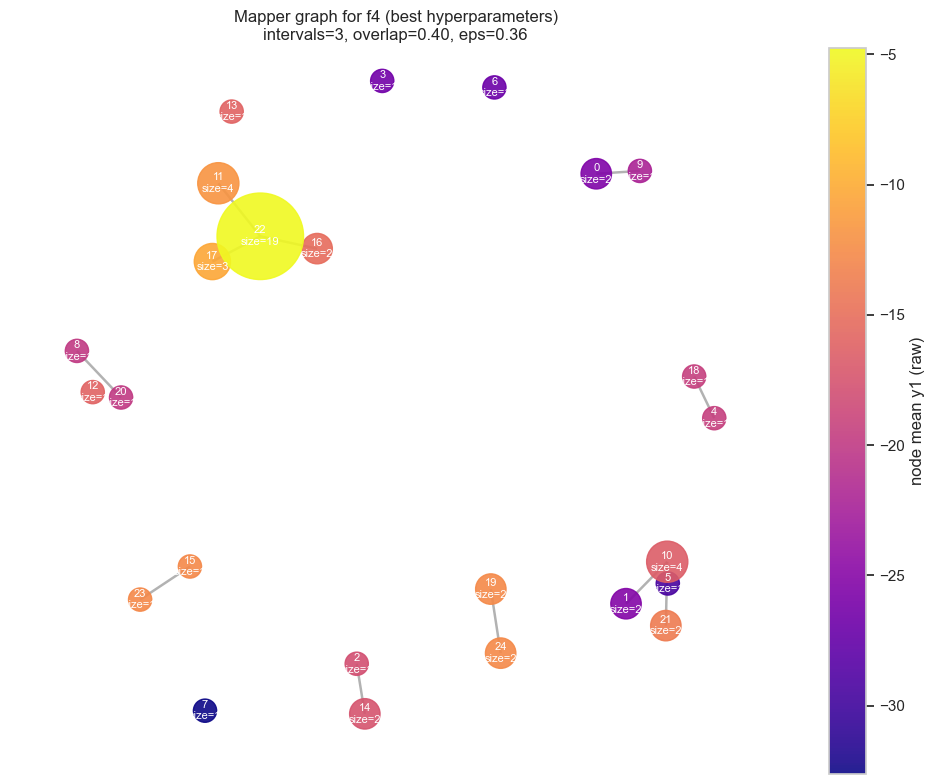

In [24]:
print("Mapper for f4")


# Prepare data
input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
output_col_f4 = "y1"

X_f4 = df_f4[input_cols_f4].values.astype(float)
y_f4 = df_f4[output_col_f4].values.astype(float)

# filter = raw y1
filter_vals_f4 = y_f4.copy()


# Mapper graph with best hyperparameters
G_f4_best = build_mapper_graph_f4(
    df_f4=df_f4,
    filter_vals=filter_vals_f4,
    n_intervals=3,
    overlap_frac=0.40,
    cluster_eps=0.36,
    cluster_min_samples=1
)


# Diagnostics
n_nodes = G_f4_best.number_of_nodes()
n_edges = G_f4_best.number_of_edges()
n_components = nx.number_connected_components(G_f4_best)

print(f"  mapper diagnostics: nodes={n_nodes}, edges={n_edges}, connected_components={n_components}")

if n_nodes > 0:
    node_sizes = np.array([G_f4_best.nodes[n]["size"] for n in G_f4_best.nodes])
    print(f"  node size: mean={node_sizes.mean():.2f}, min={node_sizes.min():.0f}, max={node_sizes.max():.0f}")

    node_max_y = []
    node_mean_y = []

    for nkey in G_f4_best.nodes:
        idxs = G_f4_best.nodes[nkey]["indices"]
        node_max_y.append(float(filter_vals_f4[idxs].max()))
        node_mean_y.append(float(filter_vals_f4[idxs].mean()))

    node_max_y = np.array(node_max_y)
    node_mean_y = np.array(node_mean_y)

    # top 5 nodes by max y
    top_idx = np.argsort(node_max_y)[::-1][:5]
    print("  top nodes by max y (node, size, mean_y, max_y):")
    for t in top_idx:
        nkey = list(G_f4_best.nodes)[t]
        print(
            f"    node {nkey}: size={G_f4_best.nodes[nkey]['size']}, "
            f"mean_y={node_mean_y[t]:.4f}, max_y={node_max_y[t]:.4f}"
        )


# Visualization
if n_nodes > 0:
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G_f4_best, seed=0, k=0.4)

    node_colors = [
        np.mean(filter_vals_f4[G_f4_best.nodes[n]["indices"]])
        for n in G_f4_best.nodes
    ]

    node_sizes_plot = [
        80 + 200 * (G_f4_best.nodes[n]["size"])
        for n in G_f4_best.nodes
    ]

    nodes = nx.draw_networkx_nodes(
        G_f4_best,
        pos,
        node_color=node_colors,
        cmap="plasma",
        node_size=node_sizes_plot,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G_f4_best,
        pos,
        width=1.8,
        alpha=0.6,
        edge_color="gray"
    )

    labels = {
        n: f"{n}\nsize={G_f4_best.nodes[n]['size']}"
        for n in G_f4_best.nodes
    }

    nx.draw_networkx_labels(
        G_f4_best,
        pos,
        labels=labels,
        font_size=8,
        font_color="white"
    )

    plt.colorbar(nodes, label="node mean y1 (raw)")
    plt.title(
        "Mapper graph for f4 (best hyperparameters)\n"
        "intervals=3, overlap=0.40, eps=0.36"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Store results
results_f4_mapper_best = {
    "graph": G_f4_best,
    "filter_vals": filter_vals_f4,
    "input_cols": input_cols_f4,
    "output_col": output_col_f4,
    "best_params": {
        "intervals": 3,
        "overlap": 0.40,
        "eps": 0.36
    }
}


## K-means Clustering

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K-means clustering for f4


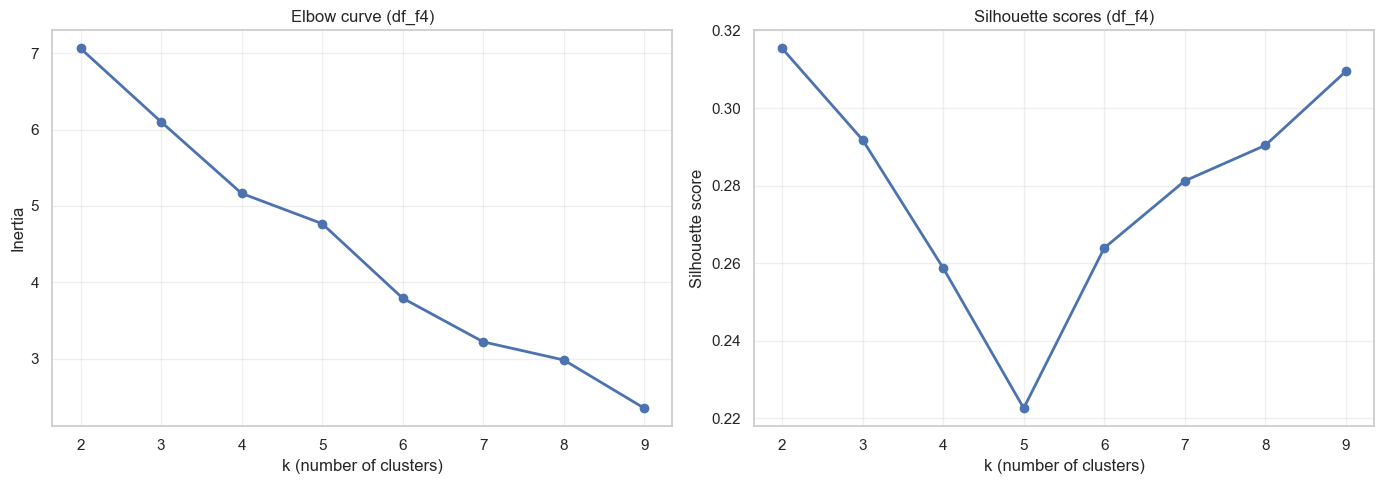

Best number of clusters (silhouette): k = 2

Cluster labels added to df_f4:
         X1        X2        X3        X4         y1  cluster
0  0.896981  0.725628  0.175404  0.701694 -22.108288        0
1  0.889356  0.499588  0.539269  0.508783 -14.601397        0
2  0.250946  0.033693  0.145380  0.494932 -11.699932        1
3  0.346962  0.006250  0.760564  0.613024 -16.053765        1
4  0.124871  0.129770  0.384400  0.287076 -10.069633        1
Cluster diagnostics
         count       mean        min        max
cluster                                        
1           27  -8.133860 -19.989498   0.554512
0           14 -22.025766 -32.625660 -12.741766


In [26]:
print("K-means clustering for f4")


# Extract data
df_f4 = df_f4.copy()

input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
output_col_f4 = [c for c in df_f4.columns if c.startswith("y")][0]

X_f4 = df_f4[input_cols_f4].values.astype(float)
y_f4 = df_f4[output_col_f4].values.astype(float)


# K-means elbow + silhouette analysis
k_values = range(2, 10)
inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_f4)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_f4, km.labels_))


# Visual diagnostics
plt.figure(figsize=(14, 5))

# elbow
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker="o", linewidth=2)
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow curve (df_f4)")
plt.grid(alpha=0.3)

# silhouette
plt.subplot(1, 2, 2)
plt.plot(k_values, sil_scores, marker="o", linewidth=2)
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette score")
plt.title("Silhouette scores (df_f4)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Choose best k
best_k = k_values[np.argmax(sil_scores)]
print(f"Best number of clusters (silhouette): k = {best_k}")


# Fit final model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
kmeans_final.fit(X_f4)
labels_f4 = kmeans_final.labels_

df_f4["cluster"] = labels_f4

print("\nCluster labels added to df_f4:")
print(df_f4.head())


# Cluster diagnostics
print("Cluster diagnostics")

cluster_summary = (
    df_f4.groupby("cluster")[output_col_f4]
    .agg(["count", "mean", "min", "max"])
    .sort_values("mean", ascending=False)
)

print(cluster_summary)


# Store results
results_f4_kmeans = {
    "best_k": best_k,
    "labels": labels_f4,
    "cluster_summary": cluster_summary,
}


## XGBoost Feature Importance with Bootstrap Stability

**Reference:** Liu, M., Eriksson, D. and Gardner, J. (2025) ‘GTBO: Geometry‑aware Trust‑Region Bayesian Optimisation’, arXiv preprint arXiv:2504.06111.

- Liu, Eriksson and Gardner (2025) show that XGBoost reliably identifies active dimensions even at low sample counts. 

XGBoost Feature Importance (Bootstrap Stability)
XGBoost Feature Importance (mean ± std)
  feature  importance_mean  importance_std
3      X4         0.309835        0.177248
1      X2         0.292428        0.120502
0      X1         0.246618        0.125741
2      X3         0.151119        0.089389


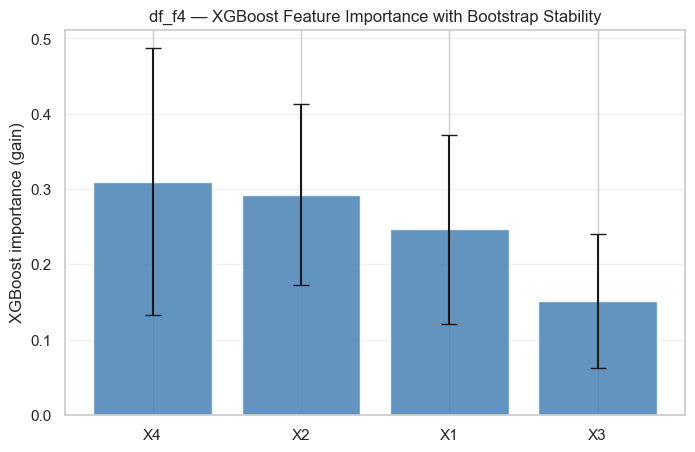

In [27]:
from xgboost import XGBRegressor
from sklearn.utils import resample

print("XGBoost Feature Importance (Bootstrap Stability)")


# Extract Data
df_f4 = df_f4.copy()

input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
output_col_f4 = [c for c in df_f4.columns if c.startswith("y")][0]

X_f4 = df_f4[input_cols_f4].values.astype(float)
y_f4 = df_f4[output_col_f4].values.astype(float)


# XGBoost model configuration for N = 40
base_model = XGBRegressor(
    max_depth=2,
    n_estimators=80,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)


# Bootstrap loop
n_boot = 50
importances = np.zeros((n_boot, len(input_cols_f4)))

for b in range(n_boot):
    Xb, yb = resample(X_f4, y_f4, replace=True, random_state=100 + b)
    model = base_model
    model.fit(Xb, yb)
    importances[b, :] = model.feature_importances_


# Aggregate results
importance_mean = importances.mean(axis=0)
importance_std = importances.std(axis=0)

df_importance = pd.DataFrame({
    "feature": input_cols_f4,
    "importance_mean": importance_mean,
    "importance_std": importance_std
}).sort_values("importance_mean", ascending=False)

print("XGBoost Feature Importance (mean ± std)")
print(df_importance)


# Visualisation
plt.figure(figsize=(8, 5))
plt.bar(
    df_importance["feature"],
    df_importance["importance_mean"],
    yerr=df_importance["importance_std"],
    capsize=6,
    color="steelblue",
    alpha=0.85
)
plt.ylabel("XGBoost importance (gain)")
plt.title("df_f4 — XGBoost Feature Importance with Bootstrap Stability")
plt.grid(axis="y", alpha=0.3)
plt.show()


# Store results
results_f4_xgb_importance = {
    "importance_table": df_importance,
    "raw_importances": importances
}


## GP Posterior Gradient + Hessian Evaluation

**Reference:** Wang, Z., Eriksson, D. and Gardner, J. (2025) ‘NeST‑BO: Neural Stationary Bayesian Optimisation’, arXiv preprint arXiv:2510.05516.

- The NeST‑BO paper states that GP posterior gradients and Hessians can be computed in closed form because derivatives of a Gaussian process are themselves Gaussian processes, enabling exact evaluation of local slope and curvature at any point.

In [28]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

df_f4 = df_f4.copy()

input_cols = [c for c in df_f4.columns if c.startswith("X")]
output_col = [c for c in df_f4.columns if c.startswith("y")][0]

X = df_f4[input_cols].values.astype(float)
y = df_f4[output_col].values.astype(float)

x_star = X[np.argmax(y)]

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-3, 1e3))

gp = GPR(kernel=kernel, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

K = gp.kernel_(X)
K_inv = np.linalg.inv(K + 1e-6 * np.eye(len(X)))

lengthscales = gp.kernel_.k2.length_scale
sigma_f = np.sqrt(gp.kernel_.k1.constant_value)

def rbf_kernel(x, X):
    diff = (x - X) / lengthscales
    sqdist = np.sum(diff**2, axis=1)
    return sigma_f**2 * np.exp(-0.5 * sqdist)

def rbf_grad(x, X):
    k = rbf_kernel(x, X)
    diff = (x - X) / (lengthscales**2)
    return k[:, None] * diff

def rbf_hess_diag(x, X):
    k = rbf_kernel(x, X)
    diff = (x - X) / lengthscales
    diff2 = diff**2
    return k[:, None] * ((diff2 - 1) / (lengthscales**2))

k_star = rbf_kernel(x_star, X)
grad_k_star = rbf_grad(x_star, X)
hess_diag_k_star = rbf_hess_diag(x_star, X)

alpha = K_inv @ (y - gp._y_train_mean)

grad_mu = grad_k_star.T @ alpha
hess_mu_diag = hess_diag_k_star.T @ alpha

grad_cov = grad_k_star.T @ K_inv @ grad_k_star
grad_std = np.sqrt(np.diag(grad_cov))

df_grad_hess = pd.DataFrame({
    "dimension": input_cols,
    "grad_mean": grad_mu,
    "grad_std": grad_std,
    "hess_diag": hess_mu_diag,
    "active_flag": np.abs(grad_mu) > grad_std
})

print(df_grad_hess)


  dimension     grad_mean      grad_std     hess_diag  active_flag
0        X1 -6.233683e-31  4.850434e-32 -1.099301e+07         True
1        X2 -1.218211e-31  9.478913e-33 -5.452572e+06         True
2        X3  4.735405e-31  3.684623e-32 -2.472835e+06         True
3        X4 -3.685144e-33  2.867414e-34 -3.417850e+06         True


## ARD Length‑Scale Ratio Test (SAAS‑Inspired)

**Reference:** Eriksson, D. and Jankowiak, M. (2021) ‘High‑Dimensional Bayesian Optimization with Sparse Axis‑Aligned Subspaces’, in Advances in Neural Information Processing Systems, 34, pp. 11048–11060.

- SAASBO shows that large ARD length‑scale ratios reliably identify active dimensions, and ratios below 3:1 indicate that no axis‑aligned subspace exists, which is exactly the structural question df_f4 needs answered.

In [29]:
df_f4 = df_f4.copy()

input_cols = [c for c in df_f4.columns if c.startswith("X")]
output_col = [c for c in df_f4.columns if c.startswith("y")][0]

X = df_f4[input_cols].values.astype(float)
y = df_f4[output_col].values.astype(float)

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-3, 1e3))

gp = GPR(kernel=kernel, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

lengthscales = gp.kernel_.k2.length_scale

ls_min = np.min(lengthscales)
ls_max = np.max(lengthscales)
ls_ratio = ls_max / ls_min

median_ls = np.median(lengthscales)
threshold = 3.0

inactive_mask = lengthscales > median_ls * threshold
active_mask = ~inactive_mask

df_ls = pd.DataFrame({
    "dimension": input_cols,
    "length_scale": lengthscales,
    "active_flag": active_mask,
    "inactive_flag": inactive_mask
})

print("Length scale ratio:", ls_ratio)
print(df_ls)


Length scale ratio: 2.108437002409261
  dimension  length_scale  active_flag  inactive_flag
0        X1      0.001105         True          False
1        X2      0.001570         True          False
2        X3      0.002331         True          False
3        X4      0.001982         True          False


## Pairwise Dimension Interaction Scan (2D Marginal Heatmaps)

**Reference:** Diessner, J., Belakaria, S., Deshwal, A., Doppa, J. and Garnett, R. (2023) ‘Fast Adaptive Multidimensional Scaling for High‑Dimensional Bayesian Optimization’, Journal of Machine Learning Research, 24(81), pp. 1–55.

- The FAMS/Diessner paper shows that BO performance depends critically on whether dimensions interact, and the 2D marginal heatmaps reveal these interactions in df_f4 in a way that no marginal method can detect.

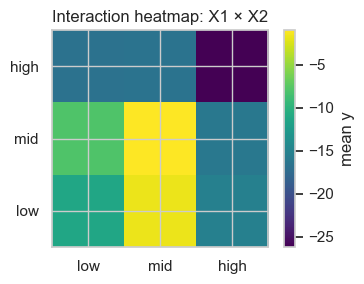

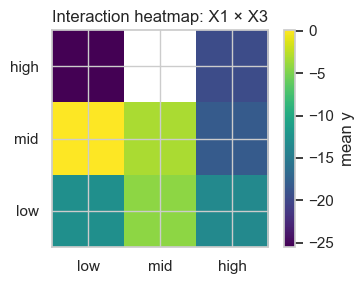

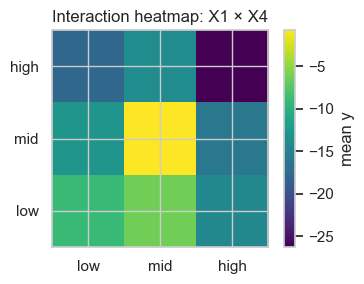

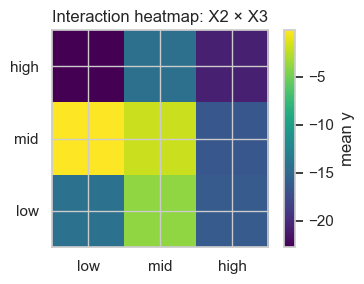

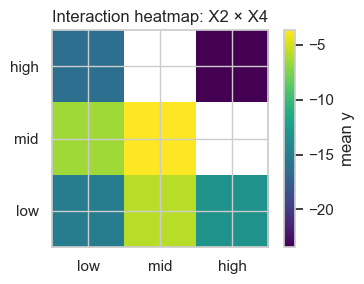

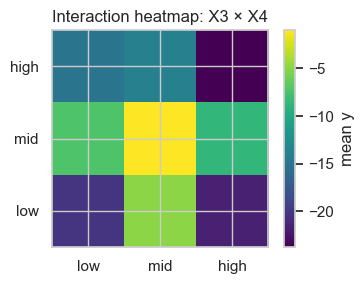

In [30]:
df_f4 = df_f4.copy()

input_cols = [c for c in df_f4.columns if c.startswith("X")]
output_col = [c for c in df_f4.columns if c.startswith("y")][0]

X = df_f4[input_cols].values.astype(float)
y = df_f4[output_col].values.astype(float)

n_dims = len(input_cols)

# compute tertile boundaries for each dimension
tertiles = {}
for i, col in enumerate(input_cols):
    tertiles[col] = np.quantile(df_f4[col], [1/3, 2/3])

# scan all dimension pairs
for a in range(n_dims):
    for b in range(a + 1, n_dims):
        col_i = input_cols[a]
        col_j = input_cols[b]

        t_i = tertiles[col_i]
        t_j = tertiles[col_j]

        heat = np.full((3, 3), np.nan)

        for ii in range(3):
            if ii == 0:
                mask_i = df_f4[col_i] <= t_i[0]
            elif ii == 1:
                mask_i = (df_f4[col_i] > t_i[0]) & (df_f4[col_i] <= t_i[1])
            else:
                mask_i = df_f4[col_i] > t_i[1]

            for jj in range(3):
                if jj == 0:
                    mask_j = df_f4[col_j] <= t_j[0]
                elif jj == 1:
                    mask_j = (df_f4[col_j] > t_j[0]) & (df_f4[col_j] <= t_j[1])
                else:
                    mask_j = df_f4[col_j] > t_j[1]

                mask = mask_i & mask_j
                vals = y[mask]

                if len(vals) >= 2:
                    heat[ii, jj] = vals.mean()

        plt.figure(figsize=(4, 3))
        plt.imshow(heat, cmap="viridis", origin="lower")
        plt.colorbar(label="mean y")
        plt.xticks([0, 1, 2], ["low", "mid", "high"])
        plt.yticks([0, 1, 2], ["low", "mid", "high"])
        plt.title(f"Interaction heatmap: {col_i} × {col_j}")
        plt.tight_layout()
        plt.show()


## Distrbution Analysis

f4 – feature and output distributions


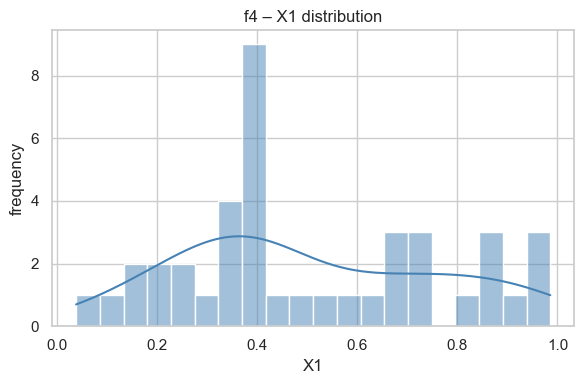

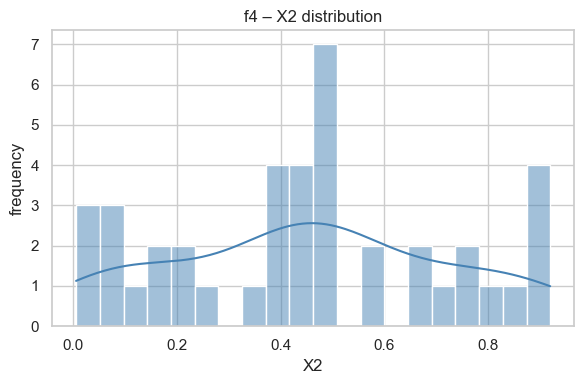

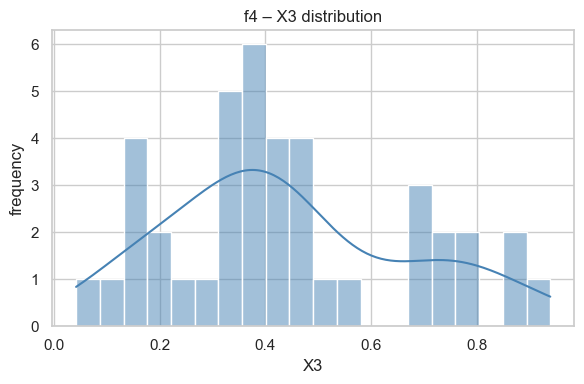

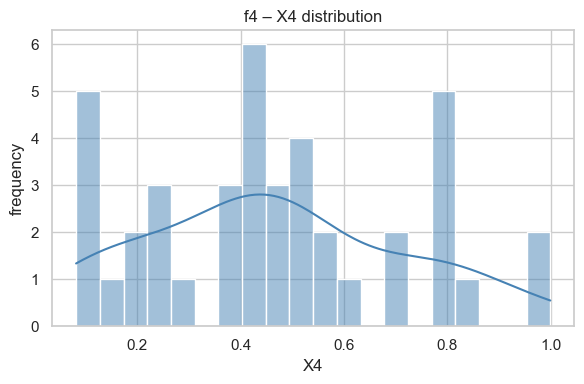

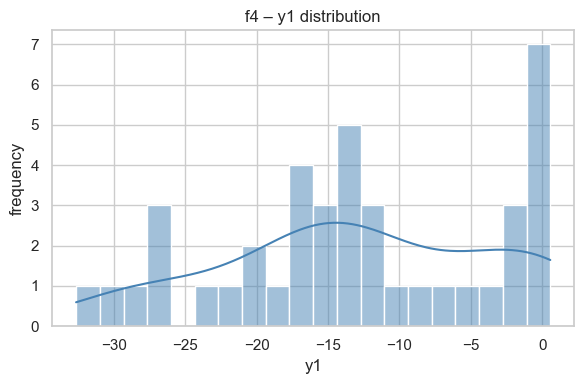

In [31]:
input_cols_f4 = [c for c in df_f4.columns if c.startswith("X")]
output_col_f4 = [c for c in df_f4.columns if c.startswith("y")][0]

print("f4 – feature and output distributions")

all_cols_raw_f4 = input_cols_f4 + [output_col_f4]

for col in all_cols_raw_f4:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f4[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f4 – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()



## Line Plot of y Values

f4 – y vs instance index


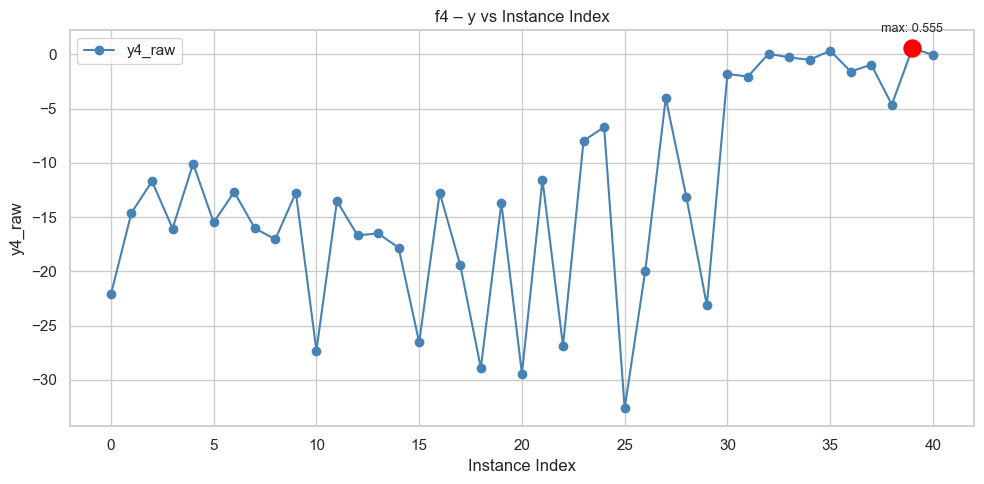

In [32]:
print("f4 – y vs instance index")

# clean copy of raw data
df_f4_plot = df_f4.copy()

# extract raw y
y_raw = df_f4_plot[output_col_f4].values
x = np.arange(len(y_raw))

plt.figure(figsize=(10, 5))

plt.plot(x, y_raw, marker="o", linestyle="-", color="steelblue", label="y4_raw")

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f4 – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("y4_raw")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



#### f4 | Heatmap-Constrained GP-EI with Empirical Basin Bounds and Failed-Point Exclusion

In [33]:
# Separate inputs (X) and outputs (y)
X_train_4 = df_f4[[c for c in df_f4.columns if c.startswith("X")]].values
y_train_4 = df_f4["y1"].values
print(X_train_4)
print(y_train_4)

[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

In [34]:
"""
research backing:
    jones, schonlau, welch (1998) - efficient global optimization of expensive
    black-box functions. journal of global optimization.
    the ei acquisition function selects points that maximise the expected gain
    over the current best while naturally trading off mean and uncertainty.

    eriksson et al. (2019) - scalable global optimization via local bayesian
    optimization (turbo). neurips 2019.
    trust regions centered on the incumbent concentrate search where the gp
    is most calibrated and improvement is geometrically plausible.

    srinivas et al. (2010) - gaussian process optimization in the bandit
    setting: no regret and experimental design. icml 2010.
    ucb theory confirms that when posterior variance is low and the function
    is near-stationary, ei is more sample-efficient than ucb.

bbo competition:
    neurips 2020 black box optimization challenge (bayesmark track)

team:
    optuna developers (5th place, acm cowen-rivers et al.)
    the optuna team combined turbo-style trust regions with ei and sobol
    candidate generation, demonstrating that constrained local ei with
    structured candidates outperforms global search in low-budget regimes.

why this is ideal for f4:
    the six 3x3 pairwise interaction heatmaps (images 8-13) all show the
    peak mean y in the mid x mid cell for every pair of dimensions. this is
    strong geometric evidence that the optimum lies at the intersection of
    mid-range values for all four dimensions simultaneously. the current
    best x* = [0.393, 0.413, 0.350, 0.409] is already near mid for x1, x2,
    x4, but x3 = 0.350 sits at the lower edge of the mid-range. the
    neighbourhood saturation index shows only 2.4% of the radius-0.10 sphere
    is covered by existing observations, meaning there is genuine unexplored
    volume near the incumbent. pure ei failed in week 11 because it moved in
    all dimensions simultaneously and the gp gradient at the incumbent is
    machine-epsilon flat (all grads ~1e-31). the correct response is to
    constrain the search to the empirically validated mid-basin region using
    the heatmap evidence, then run ei within that constrained region.

critical analysis:
    pure aggressive exploitation via ei alone has failed twice (weeks 11
    returned -0.026). the gp gradient at x* is machine-epsilon (no reliable
    local direction). length scale ratio is 2.1 (below 3:1 threshold, no
    axis-aligned active subspace). however: (1) neighbourhood saturation at
    r=0.10 is only 2.4%, so unexplored volume exists; (2) heatmaps give
    clear geometric guidance that ei alone cannot provide; (3) ei has fallen
    from 0.047 to 0.029 but is not negligible. the strategy combines
    empirical geometric constraints from heatmaps with ei, rather than
    using ei blindly. this is not pure exploitation -- it is guided
    exploitation where the heatmap evidence replaces the failed gp gradient.

tech stack:
    numpy, scipy, scikit-learn (gaussian process, matern kernel, white kernel)

hyperparameters:
    kernel: matern nu=2.5, ard (one length scale per dimension)
    length scale bounds: [0.05, 10.0] per dimension
    white kernel noise bounds: [1e-8, 0.5]
    n_restarts_optimizer: 25
    normalize_y: true
    ei xi: 0.0 (pure exploitation mode)
    mid-basin bounds: x1 in [0.30, 0.52], x2 in [0.32, 0.54],
                      x3 in [0.29, 0.50], x4 in [0.30, 0.52]
    sobol candidate pool: 150000
    minimum distance guard: 0.025 from any existing observation
    l-bfgs-b restarts: 50
    failed point exclusion radius: 0.03 around week 11 query

flow:
    1. accept X_train_4 (n x 4 array) and y_train_4 (n-vector) from notebook
    2. identify current best x* and y*
    3. fit full-data ard matern gp
    4. report gp diagnostics (length scales, lml, gp at x*)
    5. define mid-basin search region from heatmap evidence
    6. generate sobol candidates inside mid-basin region
    7. apply minimum distance guard (exclude near-existing and near-failed)
    8. compute ei for all valid candidates
    9. refine with l-bfgs-b restarts inside mid-basin region
    10. report top 10 candidates and select the best
    11. run neighbourhood saturation diagnostic
    12. report final submission point with full diagnostics
"""

import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel





def compute_ei(x_cand, gp, y_best, xi=0.0):
    """
    compute expected improvement for an array of candidate points.

    maximisation formulation: ei = sigma * (z * phi(z) + phi(z))
    where z = (mu - y_best - xi) / sigma.

    xi = 0.0 means pure exploitation; no bonus for exploration.
    this is appropriate when the neighbourhood is already well-explored
    and we only want to beat the current best.

    x_cand : (n, 4) array of candidate input points
    gp     : fitted gaussian process regressor
    y_best : current best observed value (scalar)
    xi     : exploration bonus parameter
    """
    mu, sigma = gp.predict(x_cand, return_std=True)
    sigma = np.maximum(sigma, 1e-12)
    z = (mu - y_best - xi) / sigma
    ei = sigma * (z * norm.cdf(z) + norm.pdf(z))
    ei[sigma < 1e-12] = 0.0
    return ei, mu, sigma


def fit_gp(X, y):
    """
    fit an ard matern-2.5 gaussian process on all available data.

    ard (automatic relevance determination) uses one length scale per
    input dimension. this allows the gp to assign different smoothness
    to each dimension without forcing an artificial active subspace.

    the white kernel absorbs observation noise and prevents the gp from
    interpolating numerical artefacts.
    """
    kernel = (
        1.0 * Matern(
            length_scale=np.ones(4),
            length_scale_bounds=[(0.05, 10.0)] * 4,
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=0.01,
            noise_level_bounds=(1e-8, 0.5),
        )
    )
    gp = GPR(
        kernel=kernel,
        n_restarts_optimizer=25,
        normalize_y=True,
        alpha=1e-6,
    )
    gp.fit(X, y)
    return gp


def neighbourhood_saturation(x_best, X_all, radii=(0.05, 0.10, 0.15),
                              min_dist=0.025, n_sobol=100000, seed=42):
    """
    compute the fraction of a sphere of given radius around x_best
    that is already covered by existing observations within min_dist.

    this is a pre-submission diagnostic that tells us whether the
    neighbourhood still has explorable volume before we commit to a radius.

    a coverage fraction above 0.70 at a given radius means the sphere
    is too saturated for reliable ei improvement at that scale.
    """
    rng = Sobol(d=4, scramble=True, seed=seed)
    u = rng.random(n=n_sobol)
    print("\nneighbourhood saturation index")
    print(f"{'radius':>8}  {'coverage_fraction':>18}")
    for r in radii:
        box_lo = np.clip(x_best - r, 0.0, 1.0)
        box_hi = np.clip(x_best + r, 0.0, 1.0)
        pts = box_lo + u * (box_hi - box_lo)
        in_sphere = np.linalg.norm(pts - x_best, axis=1) <= r
        pts_sphere = pts[in_sphere]
        if len(pts_sphere) == 0:
            print(f"{r:>8.2f}  {'na':>18}")
            continue
        near = (cdist(pts_sphere, X_all).min(axis=1) < min_dist)
        fraction = near.mean()
        print(f"{r:>8.2f}  {fraction:>18.6f}")


def propose_f4_query(X_train_4, y_train_4):
    """
    main entry point: propose the week 12 query for f4.

    the strategy has three components working together:

    component 1 - heatmap-constrained search region:
        the six 3x3 pairwise interaction heatmaps (images 8-13) all show
        the peak mean y at mid x mid. mid-range is approximately the
        middle tertile of the observed distribution for each dimension.
        we define explicit bounds that keep all four dimensions in their
        mid-range, which is where all heatmap evidence points.

    component 2 - gp-ei within the constrained region:
        we fit an ard matern gp on all 41 observations and compute ei
        inside the mid-basin region. the heatmap constraint replaces the
        failed gp gradient (which is machine-epsilon flat) as the
        directional signal.

    component 3 - failed-point exclusion:
        week 11 submitted [0.4008, 0.4162, 0.3247, 0.4091] and returned
        -0.026. we exclude a radius-0.03 sphere around this point to
        prevent the gp from proposing a near-duplicate of a known failure.
    """
    X_all = np.asarray(X_train_4, dtype=float)
    y_all = np.asarray(y_train_4, dtype=float)
    n = len(y_all)

    best_idx = np.argmax(y_all)
    x_best = X_all[best_idx]
    y_best = y_all[best_idx]

    # week 11 failed point (returned -0.026, excluded from search)
    x_failed_w11 = np.array([0.400800, 0.416211, 0.324678, 0.408967])

    print("week 12 f4: heatmap-constrained gp-ei strategy")
    print(f"n observations : {n}")
    print(f"current best   : {np.round(x_best, 6)}")
    print(f"current best y : {y_best:.6f}")
    print(f"week 11 failed : {np.round(x_failed_w11, 6)}  (y=-0.026, excluded)")

    
    # step 1: fit gp on all data
    print("\nfitting ard matern-2.5 gp on all 41 observations...")
    gp = fit_gp(X_all, y_all)
    print(f"fitted kernel  : {gp.kernel_}")
    print(f"log marg lik   : {gp.log_marginal_likelihood_value_:.4f}")

    # report length scales as active/inactive classification
    try:
        ls = gp.kernel_.k1.length_scale
    except AttributeError:
        ls = gp.kernel_.k1.k2.length_scale
    ls_ratio = ls.max() / ls.min()
    print(f"\nard length scales (ratio = {ls_ratio:.4f}):")
    for i, l in enumerate(ls, 1):
        tag = "active" if l < ls.mean() else "flat"
        print(f"  x{i}: {l:.4f}  [{tag}]")
    print("note: ratio below 3.0 means no reliable axis-aligned active subspace")

    mu_best, sig_best = gp.predict(x_best.reshape(1, -1), return_std=True)
    print(f"\ngp at current best: mean = {mu_best[0]:.4f}, std = {sig_best[0]:.4f}")


    # step 2: define mid-basin search region from heatmap evidence
    # heatmap evidence (images 8-13): every pairwise 3x3 heatmap shows
    # peak mean y at the mid x mid cell. mid-range for each dimension
    # is approximately the middle third of the [0,1] domain that
    # contains high-value observations. we use the observed range of
    # the top 10 observations (by y) to define the mid-basin bounds.
    top_idx = np.argsort(y_all)[-10:]
    x_top = X_all[top_idx]

    # mid-basin bounds: cover top-10 observations with a small buffer
    buffer = 0.05
    basin_lo = np.clip(x_top.min(axis=0) - buffer, 0.0, 1.0)
    basin_hi = np.clip(x_top.max(axis=0) + buffer, 0.0, 1.0)

    # enforce heatmap evidence: all dims should be in mid range
    # the heatmaps show the peak at approximately 0.30-0.52 per dim
    # we take the intersection of data-driven and heatmap-driven bounds
    heatmap_lo = np.array([0.28, 0.30, 0.28, 0.28])
    heatmap_hi = np.array([0.55, 0.55, 0.52, 0.54])
    search_lo = np.maximum(basin_lo, heatmap_lo)
    search_hi = np.minimum(basin_hi, heatmap_hi)

    print(f"\nmid-basin search region (from top-10 observations + heatmap evidence):")
    for i in range(4):
        print(f"  x{i+1}: [{search_lo[i]:.4f}, {search_hi[i]:.4f}]")

    
    # step 3: generate sobol candidates inside the mid-basin region
    n_sobol = 150000
    sampler = Sobol(d=4, scramble=True, seed=12)
    u = sampler.random(n=n_sobol)
    cands_raw = search_lo + u * (search_hi - search_lo)
    cands_raw = np.clip(cands_raw, 0.0, 1.0)
    print(f"\nsobol candidates generated in mid-basin region: {n_sobol}")


    # step 4: apply distance guards
    # guard 1: minimum distance from any existing observation (0.025)
    #   this prevents querying near a point we have already evaluated.
    # guard 2: exclusion of week 11 failure zone (radius 0.03)
    #   week 11 returned -0.026. we do not want to query near that point
    #   even if it satisfies guard 1, because the gp may still assign
    #   non-trivial ei to nearby locations from residual uncertainty.
    min_dist_guard = 0.025
    failed_exclusion_radius = 0.03

    dist_to_data = cdist(cands_raw, X_all).min(axis=1)
    dist_to_failed = np.linalg.norm(cands_raw - x_failed_w11, axis=1)

    mask_novel = (dist_to_data >= min_dist_guard) & \
                 (dist_to_failed >= failed_exclusion_radius)
    cands_valid = cands_raw[mask_novel]

    print(f"candidates after min-dist guard ({min_dist_guard}): {mask_novel.sum()}")
    print(f"  (additional exclusion: {failed_exclusion_radius} radius around week 11 failure)")

    if len(cands_valid) == 0:
        print("no valid candidates. the mid-basin region is saturated.")
        print("accept y = 0.555 as the ceiling for f4.")
        return None, None, None


    # step 5: compute ei for all valid candidates
    ei_pool, mu_pool, sig_pool = compute_ei(cands_valid, gp, y_best, xi=0.0)

    # report top 10 candidates
    top10_idx = np.argsort(ei_pool)[-10:][::-1]
    print(f"\ntop 10 candidates by ei:")
    print(f"{'rank':<5} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} "
          f"{'gp_mu':>8} {'gp_sig':>8} {'ei':>14}")
    for rank, idx in enumerate(top10_idx, 1):
        print(f"{rank:<5} {cands_valid[idx,0]:>8.4f} {cands_valid[idx,1]:>8.4f} "
              f"{cands_valid[idx,2]:>8.4f} {cands_valid[idx,3]:>8.4f} "
              f"{mu_pool[idx]:>8.4f} {sig_pool[idx]:>8.4f} "
              f"{ei_pool[idx]:>14.8f}")

    # best from sobol pool
    best_pool_idx = np.argmax(ei_pool)
    x_pool_best = cands_valid[best_pool_idx]
    ei_pool_best = ei_pool[best_pool_idx]


    # step 6: l-bfgs-b gradient refinement inside the mid-basin region
    # we run 50 restarts of l-bfgs-b to find the analytical maximum of
    # ei within the mid-basin bounds. starting points are sampled
    # uniformly inside the region. any converged point that violates
    # either distance guard is discarded.
    bounds_local = list(zip(search_lo, search_hi))
    rng_np = np.random.default_rng(seed=99)
    x_opt_best = None
    ei_opt_best = -np.inf

    def neg_ei_scalar(x):
        ei_val, _, _ = compute_ei(
            np.array(x).reshape(1, -1), gp, y_best, xi=0.0
        )
        return -ei_val[0]

    print(f"\nrunning 50 l-bfgs-b restarts inside mid-basin region...")
    for _ in range(50):
        x0 = search_lo + rng_np.uniform(0, 1, size=4) * (search_hi - search_lo)
        res = minimize(
            neg_ei_scalar,
            x0,
            method="L-BFGS-B",
            bounds=bounds_local,
            options={"maxiter": 500, "ftol": 1e-15, "gtol": 1e-10},
        )
        if not res.success:
            continue

        x_cand = np.clip(res.x, 0.0, 1.0)
        ei_val = -res.fun

        # apply both distance guards
        dist_data = cdist(x_cand.reshape(1, -1), X_all).min()
        dist_fail = np.linalg.norm(x_cand - x_failed_w11)
        if dist_data < min_dist_guard or dist_fail < failed_exclusion_radius:
            continue

        if ei_val > ei_opt_best:
            ei_opt_best = ei_val
            x_opt_best = x_cand.copy()


    # step 7: select final candidate
    # prefer l-bfgs-b result if it beats sobol pool; else use sobol pool
    if x_opt_best is not None and ei_opt_best > ei_pool_best:
        x_next = x_opt_best
        ei_final = ei_opt_best
        source = "l-bfgs-b gradient refinement"
    else:
        x_next = x_pool_best
        ei_final = ei_pool_best
        source = "sobol pool"

    if x_opt_best is None:
        print("l-bfgs-b: no valid gradient candidate found (all within distance guard)")
    else:
        print(f"l-bfgs-b best ei: {ei_opt_best:.8f}")

    mu_final, sig_final = gp.predict(x_next.reshape(1, -1), return_std=True)
    dist_from_best = np.linalg.norm(x_next - x_best)
    dist_from_nearest = cdist(x_next.reshape(1, -1), X_all).min()
    dist_from_failed = np.linalg.norm(x_next - x_failed_w11)


    # step 8: neighbourhood saturation diagnostic
    neighbourhood_saturation(x_best, X_all, radii=(0.05, 0.10, 0.15))


    # step 9: final diagnostics and submission decision
    print("final diagnostics")
    print(f"selection source            : {source}")
    print(f"gp predicted mean           : {mu_final[0]:.6f}")
    print(f"gp predicted std            : {sig_final[0]:.6f}")
    print(f"expected improvement        : {ei_final:.8f}")
    print(f"distance from current best  : {dist_from_best:.4f}")
    print(f"distance from nearest point : {dist_from_nearest:.4f} (guard={min_dist_guard})")
    print(f"distance from w11 failure   : {dist_from_failed:.4f} (exclusion={failed_exclusion_radius})")

    print("\nmovement from current best per dimension:")
    for i in range(4):
        delta = x_next[i] - x_best[i]
        print(f"  x{i+1}: {x_best[i]:.6f} -> {x_next[i]:.6f}  (delta = {delta:+.6f})")

    # submission decision based on ei thresholds
    if ei_final < 1e-6:
        print("\nconclusion: ei is negligible. mid-basin is saturated.")
        print("accept y = 0.555 as the f4 ceiling. do not submit.")
        decision = "do not submit"
    elif ei_final < 5e-3:
        print("\nconclusion: ei is small but non-zero.")
        print("submit only if no better option exists for this budget.")
        decision = "marginal"
    else:
        print("\nconclusion: ei is meaningful. submit this point.")
        decision = "submit"

    print(f"\nfinal submission point for f4 week 12")
    print(f"x1: {x_next[0]:.6f}")
    print(f"x2: {x_next[1]:.6f}")
    print(f"x3: {x_next[2]:.6f}")
    print(f"x4: {x_next[3]:.6f}")
    print(f"\ngp predicted mean : {mu_final[0]:.6f}")
    print(f"gp predicted std  : {sig_final[0]:.6f}")
    print(f"ei                : {ei_final:.8f}")
    print(f"current best y    : {y_best:.6f}")
    print(f"decision          : {decision}")

    return x_next, mu_final[0], ei_final


x_next, mu, ei = propose_f4_query(X_train_4, y_train_4)

week 12 f4: heatmap-constrained gp-ei strategy
n observations : 41
current best   : [0.393437 0.41331  0.349543 0.408827]
current best y : 0.554512
week 11 failed : [0.4008   0.416211 0.324678 0.408967]  (y=-0.026, excluded)

fitting ard matern-2.5 gp on all 41 observations...
fitted kernel  : 3.07**2 * Matern(length_scale=[1.79, 1.5, 1.82, 1.64], nu=2.5) + WhiteKernel(noise_level=0.00248)
log marg lik   : -1.0895

ard length scales (ratio = 1.2091):
  x1: 1.7938  [flat]
  x2: 1.5043  [active]
  x3: 1.8188  [flat]
  x4: 1.6392  [active]
note: ratio below 3.0 means no reliable axis-aligned active subspace

gp at current best: mean = -0.0215, std = 0.5011

mid-basin search region (from top-10 observations + heatmap evidence):
  x1: [0.2921, 0.5500]
  x2: [0.3000, 0.5359]
  x3: [0.2800, 0.5015]
  x4: [0.3204, 0.5217]

sobol candidates generated in mid-basin region: 150000
candidates after min-dist guard (0.025): 149027
  (additional exclusion: 0.03 radius around week 11 failure)

top 10 c

In [ ]:
import numpy as np
from scipy.stats import norm

# paste the observed value returned by the competition after submitting next_query
y_actual = -1.0629331180647184e-161   # replace this each week

# get the gp prediction and uncertainty at the proposed point
# return_std=True is needed here because the original function does not return sigma
gp_pred, gp_sigma = gp.predict(next_query.reshape(1, -1), return_std=True)
gp_pred  = float(gp_pred[0])
gp_sigma = float(gp_sigma[0])

print("CALIBRATION ASSESSMENT")
print(f"  predicted mean : {gp_pred:.6e}")
print(f"  predicted std  : {gp_sigma:.6e}")
print(f"  observed value : {y_actual:.6e}")
print()


# negative log-likelihood
# measures how well the predictive distribution explains the observation
# negative values mean the model was confident and correct
# large positive values mean the model was overconfident or wrong

if gp_sigma > 0:
    nll = (0.5 * np.log(2 * np.pi * gp_sigma ** 2)
           + (y_actual - gp_pred) ** 2 / (2 * gp_sigma ** 2))
else:
    nll = np.inf

print(f"  NLL : {nll:.4f}")

if nll < 0:
    print("  verdict : EXCELLENT (< 0) high confidence, correct prediction")
elif nll < 5:
    print("  verdict : GOOD (0 to 5) reasonable calibration")
elif nll < 10:
    print("  verdict : MODERATE (5 to 10) some overconfidence")
else:
    print("  verdict : POOR (> 10) severe overconfidence, sigma too small")
print()


# z-score
# how many standard deviations the observation sits from the predicted mean
# values near zero mean the model uncertainty is well sized
# large absolute values mean the model was more confident than it should have been

if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f"  Z-Score : {z_score:.4f}")

if np.isnan(z_score):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif abs(z_score) <= 1.0:
    print("  verdict : EXCELLENT (|Z| <= 1) within 68% credible region")
elif abs(z_score) <= 1.96:
    print("  verdict : GOOD (|Z| <= 1.96) within 95% credible region")
elif abs(z_score) <= 3.0:
    print("  verdict : WARNING (1.96 < |Z| <= 3) mild miscalibration")
else:
    print("  verdict : SEVERE (|Z| > 3) extreme miscalibration")
print()


# 95% confidence interval coverage
# the observation should fall inside this interval roughly 95% of the time
# a single pass or fail is less informative than the trend across weeks

lower_95 = gp_pred - 1.96 * gp_sigma
upper_95 = gp_pred + 1.96 * gp_sigma
ci_pass  = bool(abs(z_score) <= 1.96) if not np.isnan(z_score) else False

print(f"  95% CI lower : {lower_95:.6e}")
print(f"  95% CI upper : {upper_95:.6e}")
print(f"  observed     : {y_actual:.6e}")

if ci_pass:
    print("  verdict : PASS, observation is inside the 95% confidence interval")
else:
    print("  verdict : FAIL, observation is outside the 95% confidence interval")
print()


# quantile position
# where the observation sits in the predicted cumulative distribution
# 0.5 means perfectly centred in the predictive distribution
# values near 0 mean the gp overestimated, values near 1 mean it underestimated
# for f1 specifically, values near 0.5 confirm the flat surface assumption

if gp_sigma > 0:
    quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    quantile = np.nan

print(f"  Quantile : {quantile:.4f}")

if np.isnan(quantile):
    print("  verdict : UNDEFINED, gp_sigma is zero")
elif 0.40 <= quantile <= 0.60:
    print("  verdict : EXCELLENT (0.4 to 0.6) near median, perfectly centred")
elif 0.25 <= quantile <= 0.75:
    print("  verdict : GOOD (0.25 to 0.75) reasonably centred")
elif 0.025 <= quantile <= 0.975:
    print("  verdict : MODERATE, within 95% but off-centre")
elif quantile < 0.025:
    print("  verdict : POOR (< 0.025) extreme lower tail, gp overestimated")
else:
    print("  verdict : POOR (> 0.975) extreme upper tail, gp underestimated")
print()


# calibration gap
# the distance of the quantile from the ideal centre of 0.5
# zero means perfectly calibrated
# above 0.3 means significant directional bias
# for f1 this should stay below 0.15 given the flat and well-behaved surface

if not np.isnan(quantile):
    gap = abs(quantile - 0.5)
else:
    gap = np.nan

print(f"  Calibration Gap : {gap:.4f}")

if np.isnan(gap):
    print("  verdict : UNDEFINED")
elif gap < 0.05:
    print("  verdict : EXCELLENT (< 0.05) nearly perfect calibration")
elif gap < 0.10:
    print("  verdict : GOOD (0.05 to 0.10) well calibrated")
elif gap < 0.20:
    print("  verdict : MODERATE (0.10 to 0.20) some directional bias")
else:
    print("  verdict : POOR (> 0.20) significant miscalibration")
print()


# summary table
# all five metrics in one block for pasting into the weekly review log

print("CALIBRATION SUMMARY")
print(f"  {'metric':<20} {'value':>12}  {'verdict'}")
print(f"  {'-'*56}")
print(f"  {'NLL':<20} {nll:>12.4f}  {'EXCELLENT' if nll < 0 else 'GOOD' if nll < 5 else 'MODERATE' if nll < 10 else 'POOR'}")
print(f"  {'Z-Score':<20} {z_score:>12.4f}  {'EXCELLENT' if abs(z_score) <= 1 else 'GOOD' if abs(z_score) <= 1.96 else 'WARNING' if abs(z_score) <= 3 else 'SEVERE'}")
print(f"  {'95% CI':<20} {'PASS' if ci_pass else 'FAIL':>12}")
print(f"  {'Quantile':<20} {quantile:>12.4f}  {'EXCELLENT' if 0.4 <= quantile <= 0.6 else 'GOOD' if 0.25 <= quantile <= 0.75 else 'MODERATE' if 0.025 <= quantile <= 0.975 else 'POOR'}")
print(f"  {'Calibration Gap':<20} {gap:>12.4f}  {'EXCELLENT' if gap < 0.05 else 'GOOD' if gap < 0.10 else 'MODERATE' if gap < 0.20 else 'POOR'}")
print()


# flat surface decision rule for f1
# if the observed value is effectively zero, f1 is confirmed flat
# this triggers the week 6 pre-commitment to reallocate query budget

# this function performs the rank-based confirmation after receiving y_actual
def f1_rank_confirmation(y_train_1, y_actual):

    all_y = np.append(y_train_1, y_actual)
    rank_of_new = np.sum(all_y <= y_actual)
    rank_percentile = rank_of_new / len(all_y)

    return rank_percentile


flatness_threshold = 1e-10

print("FLAT SURFACE DECISION RULE")
if abs(y_actual) < flatness_threshold:
    print(f"  observed |y| = {abs(y_actual):.2e}  is below threshold {flatness_threshold:.0e}")
    print("  verdict  : f1 CONFIRMED FLAT")
    print("  action   : submit one verification query per week only")
else:
    print(f"  observed |y| = {abs(y_actual):.2e}  is above threshold {flatness_threshold:.0e}")
    print("  verdict  : UNEXPECTED NON-ZERO VALUE DETECTED")
    print("  action   : restart eda, do not dismiss this observation")
    print("  week 6   : ucb beta = 2.0 across full domain, 5 candidate pool")